# 08 — Three independent real-data sources, combined: UAVDT + VisDrone-DET + VisDrone-VID

This project's real-data ingestion layer is built to combine an arbitrary number of
independent real-data sources for the same track, not just one -- see
`docs/DEVELOPMENT.md#obtaining-visdrone-for-augmenting-uavdt-and-a-real-data-track-for-dismount`.
This notebook exercises all three sources available today together and measures two
questions:

1. **Does concatenating VisDrone-DET and VisDrone-VID with UAVDT improve the real
   `vehicle_of_interest` detector's Day/Night F1**, over training on UAVDT alone (same
   `DAY_TRAIN_SEQS`/`DAY_VAL_SEQS`/`NIGHT_VAL_SEQS` split as `02_real_data_validation.ipynb`)?
2. **VisDrone is the first real-data source for `dismount`** (UAVDT has no
   person/pedestrian ground truth at all) — train a 4-class (`car`/`truck`/`bus`/`dismount`)
   detector on all three sources combined and measure its dismount-specific
   precision/recall/F1 on *both* VisDrone-DET's and VisDrone-VID's own held-out val splits
   separately (not just one) — the point of using two independently-collected sources is
   checking whether the result holds on both, not just the one the training happened to
   lean on more. This can't be evaluated against UAVDT — there is no dismount ground truth
   in UAVDT to check against.

**Requires local copies of UAVDT, VisDrone2019-DET, and VisDrone2019-VID** (train+val) —
see `docs/DEVELOPMENT.md`. All three raise `FileNotFoundError` on the indexing cell if
their dataset isn't available, same as `02_real_data_validation.ipynb`.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


In [2]:
import time
import matplotlib.pyplot as plt
import torch
from torch.utils.data import ConcatDataset, DataLoader

from infrastructure_overwatch.ingest import (
    VEHICLE_GRID_H,
    VEHICLE_GRID_W,
    WORK_H,
    WORK_W,
    UAVDTIndex,
    UAVDTVehicleDataset,
    VisDroneDETIndex,
    VisDroneDETVehicleDataset,
    VisDroneVIDIndex,
    VisDroneVIDVehicleDataset,
    class_names_for_scheme,
)
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, evaluate_grid_detector, train_grid_detector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
uavdt_index = UAVDTIndex()  # reads UAVDT_ROOT
visdrone_det_index = VisDroneDETIndex()  # reads VISDRONE_ROOT
visdrone_vid_index = VisDroneVIDIndex()  # reads VISDRONE_ROOT
print(f"Using device: {device}")
print(f"UAVDT root: {uavdt_index.root}")
print(f"VisDrone root (DET+VID share one root): {visdrone_det_index.root}")

# VisDrone-VID has no day/night/fog attribute file like UAVDT's M_attr, so sequences are
# picked by spreading a stride across the full official train list (rather than the first
# few, which turn out to be pedestrian-heavy with almost no vehicles) -- and using its own
# official val sequences, all of them, as held-out data.
vid_all_train_seqs = visdrone_vid_index.list_sequences("train")
VID_TRAIN_SEQS = vid_all_train_seqs[::6][:10]
VID_VAL_SEQS = visdrone_vid_index.list_sequences("val")
print(f"VisDrone-VID: {len(vid_all_train_seqs)} train sequences available, using {len(VID_TRAIN_SEQS)}; "
      f"{len(VID_VAL_SEQS)} val sequences, using all of them")

Using device: cpu
UAVDT root: D:\FMV\UAVDT\raw
VisDrone root (DET+VID share one root): D:\FMV\VisDrone
VisDrone-VID: 56 train sequences available, using 10; 7 val sequences, using all of them


## Part 1 — does combining VisDrone-DET + VisDrone-VID with UAVDT improve the real
`vehicle_of_interest` detector?

Same UAVDT sequence split as `02_real_data_validation.ipynb`, so this is a direct extension
of that notebook's measurement rather than a new one: does adding VisDrone's two real
vehicle sources to the same UAVDT day-training data change Day/Night F1?

In [3]:
DAY_TRAIN_SEQS = ["M0101", "M0402", "M1201", "M1306"]
DAY_VAL_SEQS = ["M0403", "M1301"]
NIGHT_VAL_SEQS = ["M0601", "M0701", "M1009", "M1101"]

uavdt_train_ds = UAVDTVehicleDataset(uavdt_index, DAY_TRAIN_SEQS, stride=8, cap=80, seed=1, class_scheme="vehicle_only")
day_val_ds = UAVDTVehicleDataset(uavdt_index, DAY_VAL_SEQS, stride=10, cap=60, seed=2, class_scheme="vehicle_only")
night_val_ds = UAVDTVehicleDataset(uavdt_index, NIGHT_VAL_SEQS, stride=10, cap=50, seed=3, class_scheme="vehicle_only")
visdrone_det_train_ds = VisDroneDETVehicleDataset(visdrone_det_index, split="train", class_scheme="vehicle_only", stride=20, cap=350)
visdrone_vid_train_ds = VisDroneVIDVehicleDataset(visdrone_vid_index, split="train", seq_list=VID_TRAIN_SEQS, class_scheme="vehicle_only", stride=15, cap=30)

print(f"UAVDT day-train: {len(uavdt_train_ds)} frames   VisDrone-DET train: {len(visdrone_det_train_ds)} frames   "
      f"VisDrone-VID train: {len(visdrone_vid_train_ds)} frames   "
      f"day-val: {len(day_val_ds)} frames   night-val: {len(night_val_ds)} frames")

UAVDT day-train: 263 frames   VisDrone-DET train: 324 frames   VisDrone-VID train: 231 frames   day-val: 112 frames   night-val: 188 frames


In [4]:
uavdt_only_loader = DataLoader(uavdt_train_ds, batch_size=8, shuffle=True)
uavdt_only_model = GridDetector(n_classes=3, grid_h=VEHICLE_GRID_H, grid_w=VEHICLE_GRID_W, stage_channels=(24, 48, 96, 96))
t0 = time.time()
train_grid_detector(uavdt_only_model, uavdt_only_loader, epochs=25, device=device)
print(f"UAVDT-only done in {time.time()-t0:.1f}s")

augmented_train_ds = ConcatDataset([uavdt_train_ds, visdrone_det_train_ds, visdrone_vid_train_ds])
augmented_loader = DataLoader(augmented_train_ds, batch_size=8, shuffle=True)
augmented_model = GridDetector(n_classes=3, grid_h=VEHICLE_GRID_H, grid_w=VEHICLE_GRID_W, stage_channels=(24, 48, 96, 96))
t0 = time.time()
train_grid_detector(augmented_model, augmented_loader, epochs=25, device=device, quiet=True)
print(f"UAVDT+VisDrone-DET+VisDrone-VID done in {time.time()-t0:.1f}s on {len(augmented_train_ds)} frames")

  epoch  1/25  loss 1.2607


  epoch  5/25  loss 0.2171


  epoch 10/25  loss 0.0690


  epoch 15/25  loss 0.0438


  epoch 20/25  loss 0.0376


  epoch 25/25  loss 0.0288
UAVDT-only done in 812.9s


UAVDT+VisDrone-DET+VisDrone-VID done in 2808.5s on 818 frames


UAVDT-only           Day   F1 0.39   Night F1 0.08


UAVDT+both VisDrone  Day   F1 0.44   Night F1 0.15


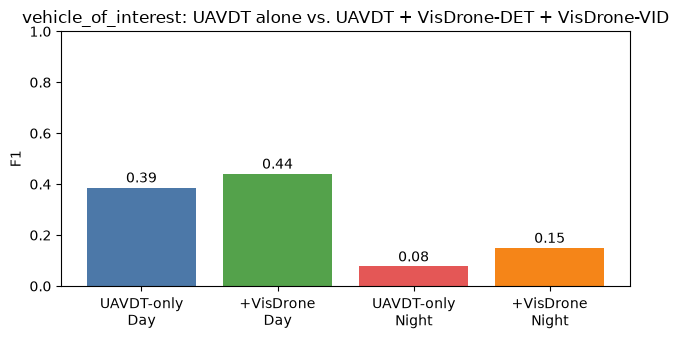

In [5]:
results = {}
for name, model in [("UAVDT-only", uavdt_only_model), ("UAVDT+both VisDrone", augmented_model)]:
    results[name] = {
        "day": evaluate_grid_detector(model, day_val_ds, WORK_W, WORK_H, device=device),
        "night": evaluate_grid_detector(model, night_val_ds, WORK_W, WORK_H, device=device),
    }
    print(f"{name:20s} Day   F1 {results[name]['day'].f1:.2f}   Night F1 {results[name]['night'].f1:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
names = ["UAVDT-only\nDay", "+VisDrone\nDay", "UAVDT-only\nNight", "+VisDrone\nNight"]
f1s = [results["UAVDT-only"]["day"].f1, results["UAVDT+both VisDrone"]["day"].f1,
       results["UAVDT-only"]["night"].f1, results["UAVDT+both VisDrone"]["night"].f1]
bars = ax.bar(names, f1s, color=["#4C78A8", "#54A24B", "#E45756", "#F58518"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1")
ax.set_title("vehicle_of_interest: UAVDT alone vs. UAVDT + VisDrone-DET + VisDrone-VID")
for b, v in zip(bars, f1s, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Part 2 — a real `dismount` track, for the first time, checked against two independent
sources

UAVDT contributes no dismount ground truth at all under `class_scheme="vehicle_dismount"`
(its category mapping is unchanged, just placed in a 4-class label space); both VisDrone
sources contribute vehicle boxes *and* dismount boxes (from `pedestrian`/`people`). Training
combines all three; evaluation is kept separate per VisDrone source rather than pooled, so
"does this generalize" can be checked against DET and VID independently.

In [6]:
uavdt_train_vd_ds = UAVDTVehicleDataset(uavdt_index, DAY_TRAIN_SEQS, stride=8, cap=80, seed=1, class_scheme="vehicle_dismount")
visdrone_det_train_vd_ds = VisDroneDETVehicleDataset(visdrone_det_index, split="train", class_scheme="vehicle_dismount", stride=20, cap=350)
visdrone_vid_train_vd_ds = VisDroneVIDVehicleDataset(visdrone_vid_index, split="train", seq_list=VID_TRAIN_SEQS, class_scheme="vehicle_dismount", stride=15, cap=30)
visdrone_det_val_vd_ds = VisDroneDETVehicleDataset(visdrone_det_index, split="val", class_scheme="vehicle_dismount", stride=2, cap=150)
visdrone_vid_val_vd_ds = VisDroneVIDVehicleDataset(visdrone_vid_index, split="val", seq_list=VID_VAL_SEQS, class_scheme="vehicle_dismount", stride=10, cap=15)

vd_train_ds = ConcatDataset([uavdt_train_vd_ds, visdrone_det_train_vd_ds, visdrone_vid_train_vd_ds])
vd_loader = DataLoader(vd_train_ds, batch_size=8, shuffle=True)
vd_model = GridDetector(n_classes=4, grid_h=VEHICLE_GRID_H, grid_w=VEHICLE_GRID_W, stage_channels=(24, 48, 96, 96))
t0 = time.time()
train_grid_detector(vd_model, vd_loader, epochs=25, device=device)
print(f"vehicle_dismount model trained in {time.time()-t0:.1f}s on {len(vd_train_ds)} frames "
      f"({len(uavdt_train_vd_ds)} UAVDT + {len(visdrone_det_train_vd_ds)} VisDrone-DET + "
      f"{len(visdrone_vid_train_vd_ds)} VisDrone-VID)")

  epoch  1/25  loss 1.6524


  epoch  5/25  loss 0.8978


  epoch 10/25  loss 0.4495


  epoch 15/25  loss 0.2214


  epoch 20/25  loss 0.1364


  epoch 25/25  loss 0.3046
vehicle_dismount model trained in 2802.3s on 818 frames (263 UAVDT + 324 VisDrone-DET + 231 VisDrone-VID)


In [7]:
from infrastructure_overwatch.geometry import iou_xyxy
from infrastructure_overwatch.grid_codec import decode_grid_predictions


def evaluate_single_class(model, dataset, class_idx, thresh=0.4, iou_thresh=0.3, n=None):
    n = len(dataset) if n is None else min(n, len(dataset))
    tp = fp = fn = 0
    model.eval()
    with torch.no_grad():
        for i in range(n):
            img, label = dataset[i]
            pred = model(torch.as_tensor(img).unsqueeze(0).to(device))[0].cpu()
            pred_boxes = [b for b in decode_grid_predictions(pred, WORK_W, WORK_H, model.grid_w, model.grid_h, thresh=thresh) if b[5] == class_idx]
            gt_boxes = [b for b in decode_grid_predictions(torch.as_tensor(label), WORK_W, WORK_H, model.grid_w, model.grid_h, thresh=0.5, nms_iou=1.1) if b[5] == class_idx]
            matched: set[int] = set()
            for pb in pred_boxes:
                best_iou, best_j = 0.0, -1
                for j, gb in enumerate(gt_boxes):
                    if j in matched:
                        continue
                    v = iou_xyxy(pb[:4], gb[:4])
                    if v > best_iou:
                        best_iou, best_j = v, j
                if best_iou >= iou_thresh:
                    tp += 1
                    matched.add(best_j)
                else:
                    fp += 1
            fn += len(gt_boxes) - len(matched)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


dismount_idx = class_names_for_scheme("vehicle_dismount").index("dismount")
for val_name, val_ds in [("VisDrone-DET val", visdrone_det_val_vd_ds), ("VisDrone-VID val", visdrone_vid_val_vd_ds)]:
    dp, dr, df1 = evaluate_single_class(vd_model, val_ds, dismount_idx)
    overall = evaluate_grid_detector(vd_model, val_ds, WORK_W, WORK_H, device=device)
    print(f"{val_name:18s} dismount-only -> precision {dp:.2f}  recall {dr:.2f}  F1 {df1:.2f}   "
          f"|   all 4 classes F1 {overall.f1:.2f}")

VisDrone-DET val   dismount-only -> precision 0.07  recall 0.04  F1 0.05   |   all 4 classes F1 0.15


VisDrone-VID val   dismount-only -> precision 0.06  recall 0.04  F1 0.05   |   all 4 classes F1 0.14


## Takeaway

Read both measurements above at face value rather than assuming either "more data always
helps" or "a new real class works immediately, the same way on every source" — see the
printed numbers for what this run actually found, including whether the dismount channel's
accuracy on VisDrone-DET and VisDrone-VID val agree or diverge (a real discrepancy between
the two would itself be a finding worth keeping, not a bug to average away). Whatever the
result, `docs/VALIDATION.md` and `docs/METHODOLOGY_AND_LIMITATIONS.md` should be updated
with these exact numbers rather than left as the "not yet exercised" placeholder they
started as before this notebook ran.